<a href="https://colab.research.google.com/github/farinaz-hatami/Module-3-Assignments/blob/main/OMDS_MODEB2_WEEK5_HATAMI_FARINAZ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5 - Bivariate Analysis

## Please run the cells of the notebook as you get to them while reading

In [3]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns

# 1. Lesson: Bivariate graphs

In this lesson, we'll consider some bivariate plots: scatter plots, line plots, waterfall plots, area plots, and pair plots.  We'll also look at bivariate statistics such as correlations, ratios, and percentages.  First, let's create some data.

In [4]:
np.random.seed(0)
numpoints = 100
lesson_series_uniform = np.round(np.random.random(size = numpoints) * 100, 2)
lesson_series_base = np.round(np.random.random(size = numpoints)**2 * 100, 2)
lesson_series_skewed = lesson_series_base + np.random.normal(scale = 10, size = numpoints)
lesson_series_reverse = 100 - lesson_series_base + np.random.normal(scale = 10, size = numpoints)

This scatter plot puts one series against another.  The two series are anticorrelated - one goes up when the other goes down.

<Axes: >

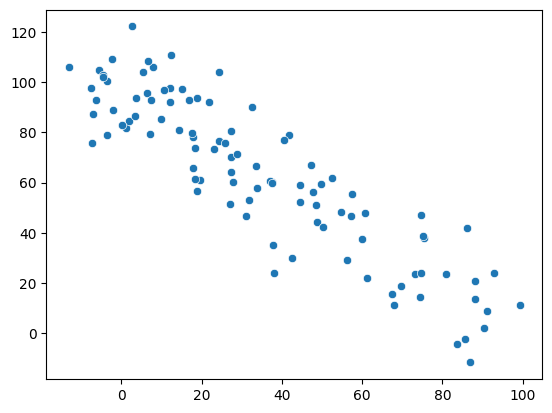

In [5]:
sns.scatterplot(x = lesson_series_skewed, y = lesson_series_reverse)

This pair plot compares three series against one another.  The diagonal shows the histogram of each series, while the non-diagonal entries plot two different series against each other.  The result in column 1, row 2 is a scatter plot that compares series #1 with series #2.  In effect, when the logic of the pair plot tells us to plot a series against itself (column 1, row 1), we draw a histogram.  (It would be silly to draw a scatter plot of a series against itself).  Because series #1 is not based on the "base" series, it is not correlated with series #2 or series #3, so the four scatter plots that compare series #1 to #2 and #3 look patternless.  The two scatter plots that compare series #2 with series #3 do appear to be correlated due to the "base" series that they share in common.

In [6]:
df = pd.DataFrame(np.array([lesson_series_uniform, lesson_series_skewed, lesson_series_reverse]).T, columns = ['uniform', 'skewed', 'reverse'])

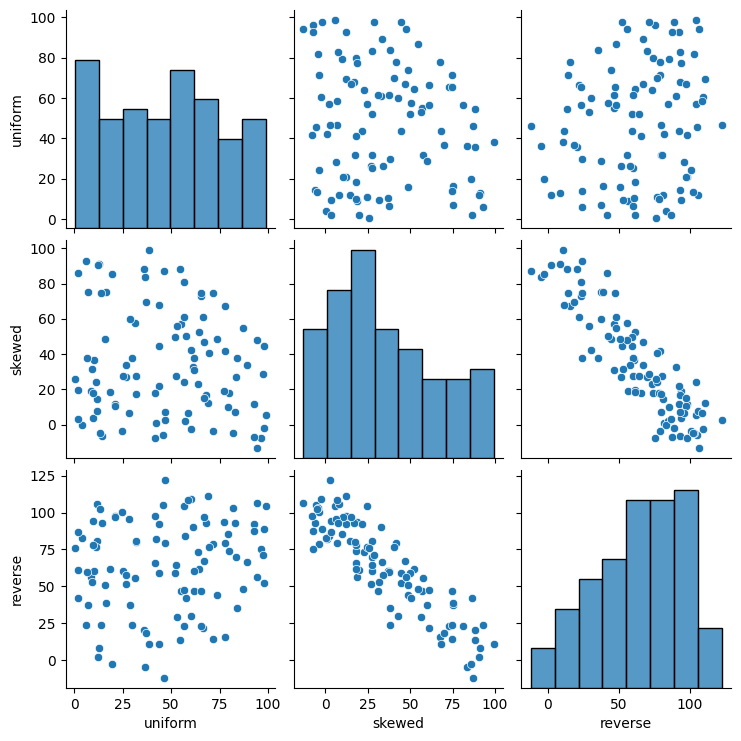

In [7]:
sns.pairplot(df)

We can compute the correlation coefficience between each pair.

In [8]:
print("Correlations:", df.corr())

Correlations:           uniform    skewed   reverse
uniform  1.000000 -0.145022  0.149771
skewed  -0.145022  1.000000 -0.894549
reverse  0.149771 -0.894549  1.000000


This shows that there is a strong negative correlation between the "skewed" and "reverse" datasets (a larger negative number in row 2, column 3 and in row 3, column 2) and almost no correlation between the "uniform" dataset and the others (the much smaller numbers at those locations in the table.)

Q: What is a correlation telling us?

If the correlation is large (close to 1) it tells us that the two variables are usually either both large or both small in value.  If we graphed them on a scatter plot, the shape would be close to a straight line, positioned diagonally from the lower left to upper right.

If the correlation is very negative (close to -1), it tells us that when one variable is large, the other is small.  If we graphed them on a scatter plot, the shape would be close to a straight line, positioned diagonally from the upper left to lower right.

If the correlation is zero, it tells us that the two variables, plotted on a scatter plot, would form a cloud.  The cloud can have different shape - for instance, it could be square or circular - but it cannot look like a diagonal line.  Knowing the value of one variable would tell you nothing about the value of the other variable.  (At least, it would not tell you whether the other variable is large or small).

The correlation coefficients above are called by the letter R.  R can be positive or negative, and lies between -1 and 1.  If we square R, we get a value called $R^2$ which is sometimes used to describe the correlation.  Unless R = 0 or 1, $R^2$ will be smaller in magnitude than R (and always positive), which means that it is very important to know if you are talking about R or $R^2$.  Since the values above can be negative, you can know for sure that they are R values, not $R^2$.

Q: How do you decide if a correlation is strong?

It depends on the application.  Some sources say that a correlation of R = 0.7 or 0.8 is strong, but in other applications (say, the social sciences) a correlation of 0.5 might be considered quite strong.  It is not unusual for social scientists to report correlations even as low a 0.2 as being important.

Q: What is the purpose of finding a correlation?

Here are a few:

1. Variables that are correlated with a target variable might be especially useful in predicting that variable.  This might also suggest that a linear model could work.  On the other hand, just because there are no pairwise correlations doesn't mean that a linear model won't work.  For example, if you select X, Y, and Z from this list of four possibilities: \[\[X = 1, Y = 0, Z = 0], \[X = 0, Y = 1, Z = 0], \[X = 0, Y = 0, Z = 1], \[X = 1, Y = 1, Z = 1]] then any two variables are completely uncorrelated, but the sum of the three is usually 1.  So the linear model Z = 1 - X - Y is accurate in three out of four cases even though all pairwise correlations are zero.

2. Variables that are very correlated with each other might be redundant.  In the extreme case, two variables that have a correlation of 1.0 are "linearly dependent" - they essentially provide the same information.  For example, if one column is a height in inches, and another is a height in centimeters, then they are redundant.  Moreover, if you use two highly correlated variables as predictors, the results will be somewhat unpredictable.  For example, if HI is the height in inches and HC is the height in centimeters, then the following formulas are all equivalent: HC, 2.54 * HI, 0.5 * HC + 1.27 * HI, 1001 * HC - 2540 * HI.  So there's no knowing which one you'll get if you try to build a model based on these variables.  The last one in particular is a little bit surprising, given the large coefficients, but it could very well be the result of a linear regression analysis.

3. Correlation can help you to detect problems with the data.  If two variables are correlated but shouldn't be, or if they're not correlated but should be, there might be something wrong with the data.  It's important to test the data to see if it makes sense.

4. Correlations can be interesting things to report.  If your client or organization is asking for a verbal explanation of the dataset, they might be interested in knowing about any correlations for reasons of their own.

A waterfall chart shows a value after a sequence of inputs and outputs.

In [9]:
import plotly.graph_objects as go

fig = go.Figure(go.Waterfall(
    name='This title is not displayed',
    orientation='v',
    measure=['absolute','relative','relative','relative','relative'],
    x=["2023-Jan", "receipts-in", "interest-in", "expenses-out", "interest-out", "2024-Jan"],
    textposition='outside',
    text=['Total','after-receipts','after-interest','after-expenses','after-interest'],
    y=[123.45,42.08,21.97,-54.31,-50.23],
    connector=dict(line=dict(color='rgb(63, 63, 63)'))
))

fig.update_layout(
    title='Waterfall Plot',
    showlegend=False
)
fig.update_yaxes(range=[-1,230])
fig.show()

A line plot is typically associated with a time or date range.  It shows how a variable rises and falls over a period of time.

/tmp/ipython-input-2082488306.py:3: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



<Axes: xlabel='None'>

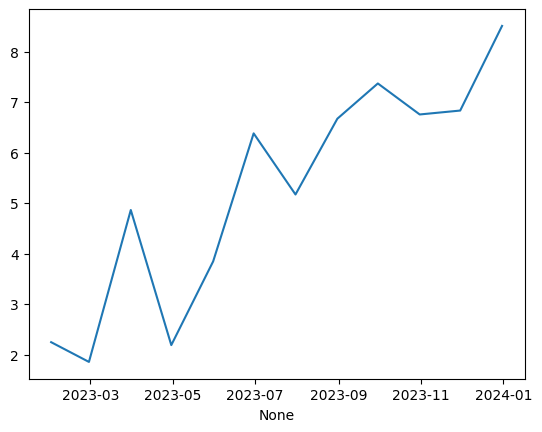

In [10]:
numdates = 12
time_series = np.random.random(size = numdates) * 5 + np.arange(numdates) / 3
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
sns.lineplot(x = datearray, y = time_series)

An area plot stacks one curve on top of another.  In the graph below, the top line shows the sum of the two series (ser1 + ser2) while the bottom line just shows ser1.

<Axes: >

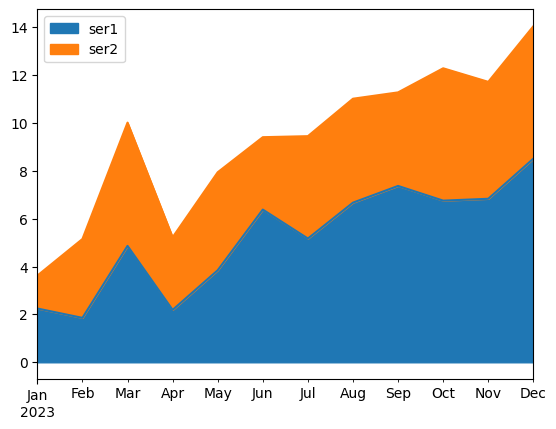

In [12]:
time_series_2 = np.random.random(size = numdates) * 5 + np.arange(numdates) / 3
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 2. Weekly graph question

Below is a pair plot showing the correlation between the levels of chemical A, B, and C in a water sample.  If you had to choose just _three_ of the nine graphs in the pair plot to display, which would you choose?  How would you alter the way these graphs are displayed to make them clearer or more informative?  Would you fit any of these graphs to a line or curve?  Why or why not?  What if you had to choose just _one_?  What if you had to choose _six_?

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns

np.random.seed(0)
num_data = 100
base_data = np.random.random(size = num_data)
chem1 = base_data + np.random.normal(size = num_data) * 0.1
chem2 = base_data**2 + np.random.normal(size = num_data) * 0.1
chem3 = 1 - base_data + np.random.normal(size = num_data) * 0.1
df_chem = pd.DataFrame({'chem1':chem1,'chem2':chem2,'chem3':chem3})

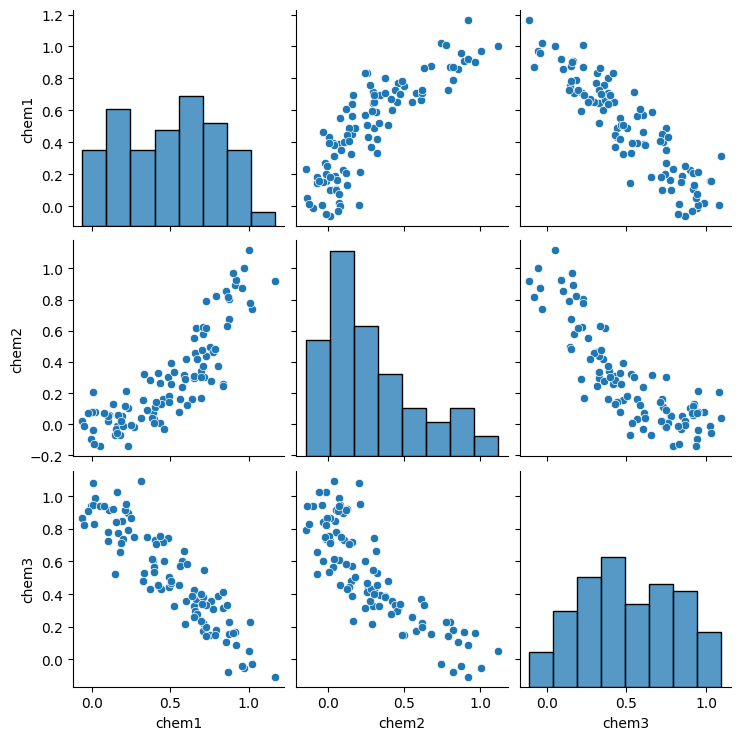

In [15]:
sns.pairplot(df_chem)

* My answer for weekly graph question:

The pair plot for chemical A (chem1), B (chem2), and C (chem3) allows us to visually assess correlations and distributions.

1) My chosen 3 graphs:

**- Scatter plot of chem1 vs chem3:**
This graph shows a strong negative correlation, meaning that when the level of one chemical increases, the other decreases. According to the lesson, correlations close to −1 appear as a clear diagonal pattern from the upper left to the lower right, making this relationship highly informative.

**- Scatter plot of chem1 vs chem2:**
This plot shows a clear relationship between the variables, although it is nonlinear because chem2 is derived from the square of the base data. Including this graph helps identify relationships that are not purely linear.

**- Scatter plot of chem2 vs chem3:**
Since both chemicals are derived from the same underlying data source, this graph still shows a noticeable relationship and helps complete the comparison among all chemical pairs.

These three scatter plots are the most useful because they directly show the bivariate relationships between different chemicals, which is the main purpose of a pair plot. The diagonal histograms mainly show distributions rather than relationships between variables, so they are less important when the goal is to analyze correlation.

* 2) How would you alter the way these graphs are displayed to make them clearer or more informative?

To make the selected graphs clearer and more informative, several visualization improvements could be applied. First, I would add clear axis labels and descriptive titles identifying each chemical so the relationships are immediately understandable. Second, I would use smaller markers or transparency (alpha adjustment) to reduce overlap between points and improve visibility in dense regions of the scatter plots. Third, I would include the correlation coefficient (R value) on each scatter plot to quantitatively summarize the strength and direction of the relationship discussed in the lesson. Additionally, using consistent axis scales across comparable plots would make relationships easier to compare. Finally, adding an appropriate trend line or curve where a clear pattern exists would help highlight the underlying relationship between variables without relying only on visual inspection.

* 3) Would you fit any of these graphs to a line or curve?Why or why not?

Yes, I would fit a line or curve to some of the graphs depending on the type of relationship shown between the variables. For the chem1 vs chem3 scatter plot, I would fit a linear regression line because the points show a strong negative correlation and follow an approximately straight diagonal pattern. A linear fit helps clearly summarize this inverse relationship.

For the chem1 vs chem2 plot, I would fit a curve (such as a polynomial trend line) rather than a straight line because the relationship appears nonlinear. Since chem2 is related to the square of the underlying data, a curved model better represents the pattern in the data.

However, I would avoid fitting a line or curve to relationships that appear weak or highly scattered, because adding a trend line where no clear correlation exists could be misleading. Trend lines should only be used when they accurately represent the relationship between variables.

4) What if you had to choose just one? What if you had to choose six?

If I had to choose just one graph, I would select the scatter plot of chem1 versus chem3. This graph shows the strongest and clearest correlation among the variables, with a noticeable negative relationship. According to the lesson, strong correlations appear as a diagonal pattern in a scatter plot, making this visualization the most informative single summary of how the chemical levels relate to each other.

If I had to choose six graphs, I would include the three scatter plots comparing each pair of chemicals (chem1 vs chem2, chem1 vs chem3, and chem2 vs chem3) along with the three diagonal histograms showing the distributions of chem1, chem2, and chem3. The scatter plots provide insight into the relationships and correlations between variables, while the histograms help explain the spread and distribution of each chemical measurement. Together, these six graphs provide both relational and distributional information about the dataset.

# 3. Homework - Reproducing Pair Plot Graphs

I'm going to show you some Pair Plot (Scatter and Histogram) graphs.  I'd like you to generate some data that will generate those graphs.

Example: this cloud involves a match between two normal distributions.

<Axes: xlabel='data1', ylabel='data2'>

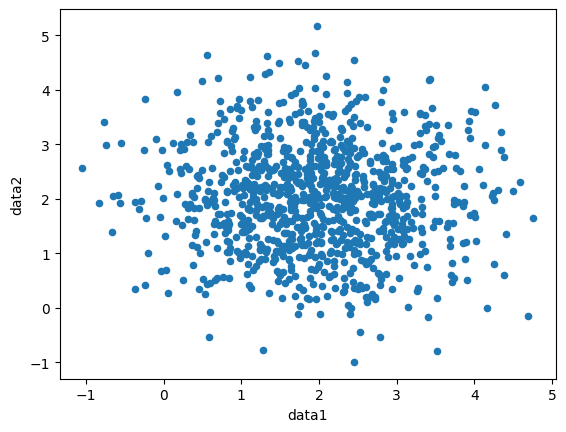

In [16]:
num_points = 1000
np.random.seed(0)
data1 = np.random.normal(size = num_points) + 2
data2 = np.random.normal(size = num_points) + 2
df_twonorm = pd.DataFrame({"data1":data1,"data2":data2})
df_twonorm.plot.scatter(x = "data1", y = "data2")

Problem: Can you design data that will generate the following scatter plot?  You may need to join multiple series to make one big series for the y-axis data.  That will allow you to create the two clouds. Use Google or ChatGPT to find the function that does that.  It is okay if the precise numbers are not re-created; just the general shape: two vertically separated clouds of points.

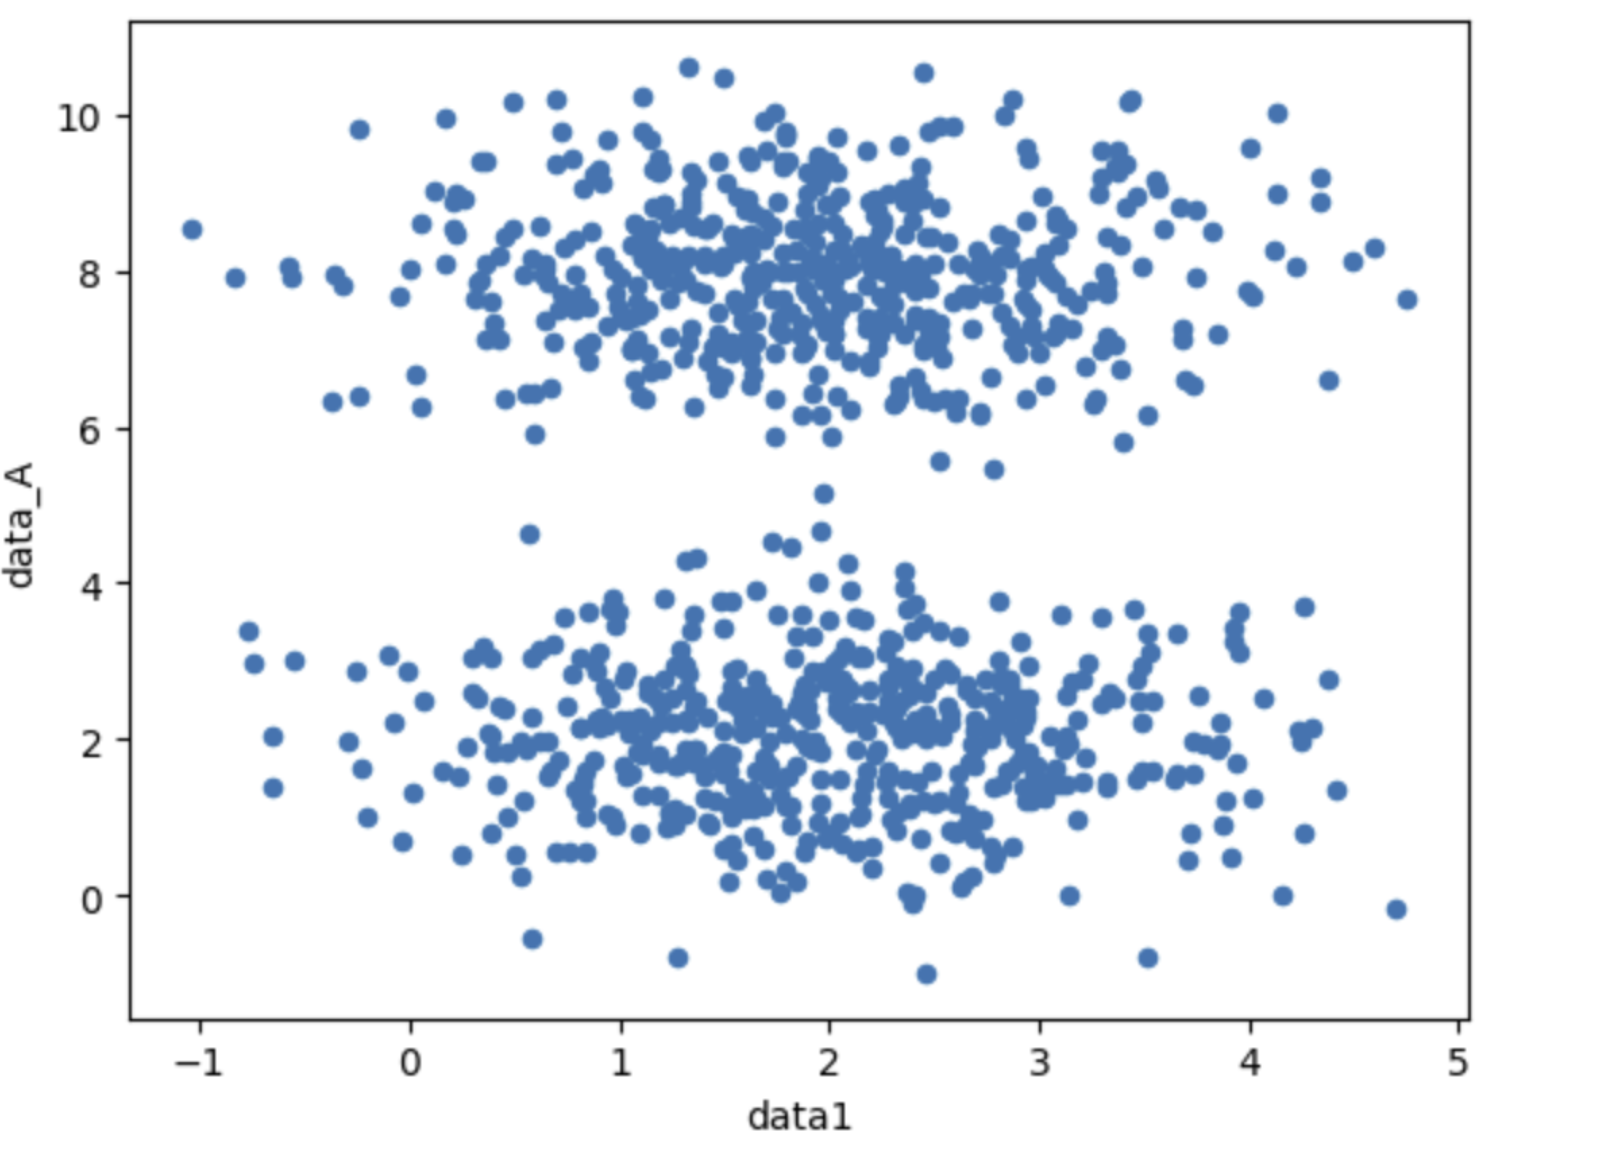

In [36]:
from IPython.display import Image
Image("twoclouds.png")

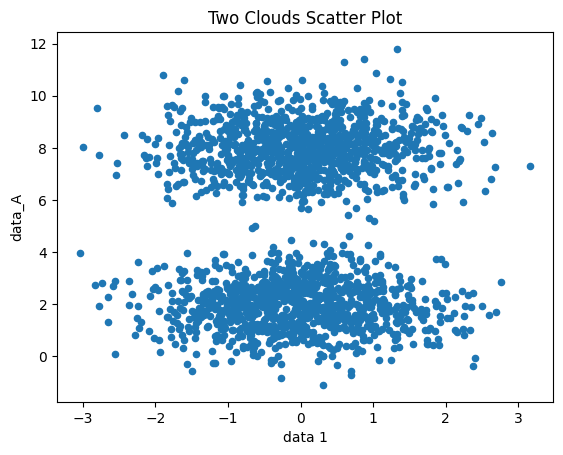

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 1000

# Similar x-values for both groups
x1 = np.random.normal(size=num_points)
x2 = np.random.normal(size=num_points)

# Two different y distributions (vertical separation)
y1 = np.random.normal(loc=2, scale=1, size=num_points)   # lower cloud
y2 = np.random.normal(loc=8, scale=1, size=num_points)   # upper cloud

# Combine the datasets
x = np.concatenate([x1, x2])
y = np.concatenate([y1, y2])

df = pd.DataFrame({"x": x, "y": y})

# Scatter plot with custom labels and title
ax = df.plot.scatter(x="x", y="y")
ax.set_xlabel("data 1")
ax.set_ylabel("data_A")
ax.set_title("Two Clouds Scatter Plot")

plt.show()

* Code Explanation:

- Two separate normal distributions are created for the y-axis.
- One distribution is centered lower (loc = 2) and the other higher (loc = 8).
- The datasets are combined using np.concatenate(), producing two vertically separated clusters.
- Because the x-values overlap, the result appears as two vertical clouds, which matches the required shape.

* My Interpretation:

The scatter plot can be generated by creating two sets of normally distributed data that share a similar range of x-values but have different average values along the y-axis. Because the x-values come from similar normal distributions, the data spreads horizontally in the same region of the plot. However, the y-values are generated with different means, causing one group of observations to appear higher than the other.

The two datasets are combined using np.concatenate(), which merges them into a single dataset while preserving the separation between the groups. This produces two distinct vertical clusters of points in the scatter plot. By adjusting the mean of each y-value distribution, the vertical distance between the clouds can be controlled while maintaining a similar spread within each group.

This demonstrates how modifying the statistical properties of generated data, particularly the mean of a distribution, directly affects the visual structure observed in bivariate scatter plots.

Challenge problem!  Hint: you will need two series, and three segments of the first series will connect with the three segments of the second series.

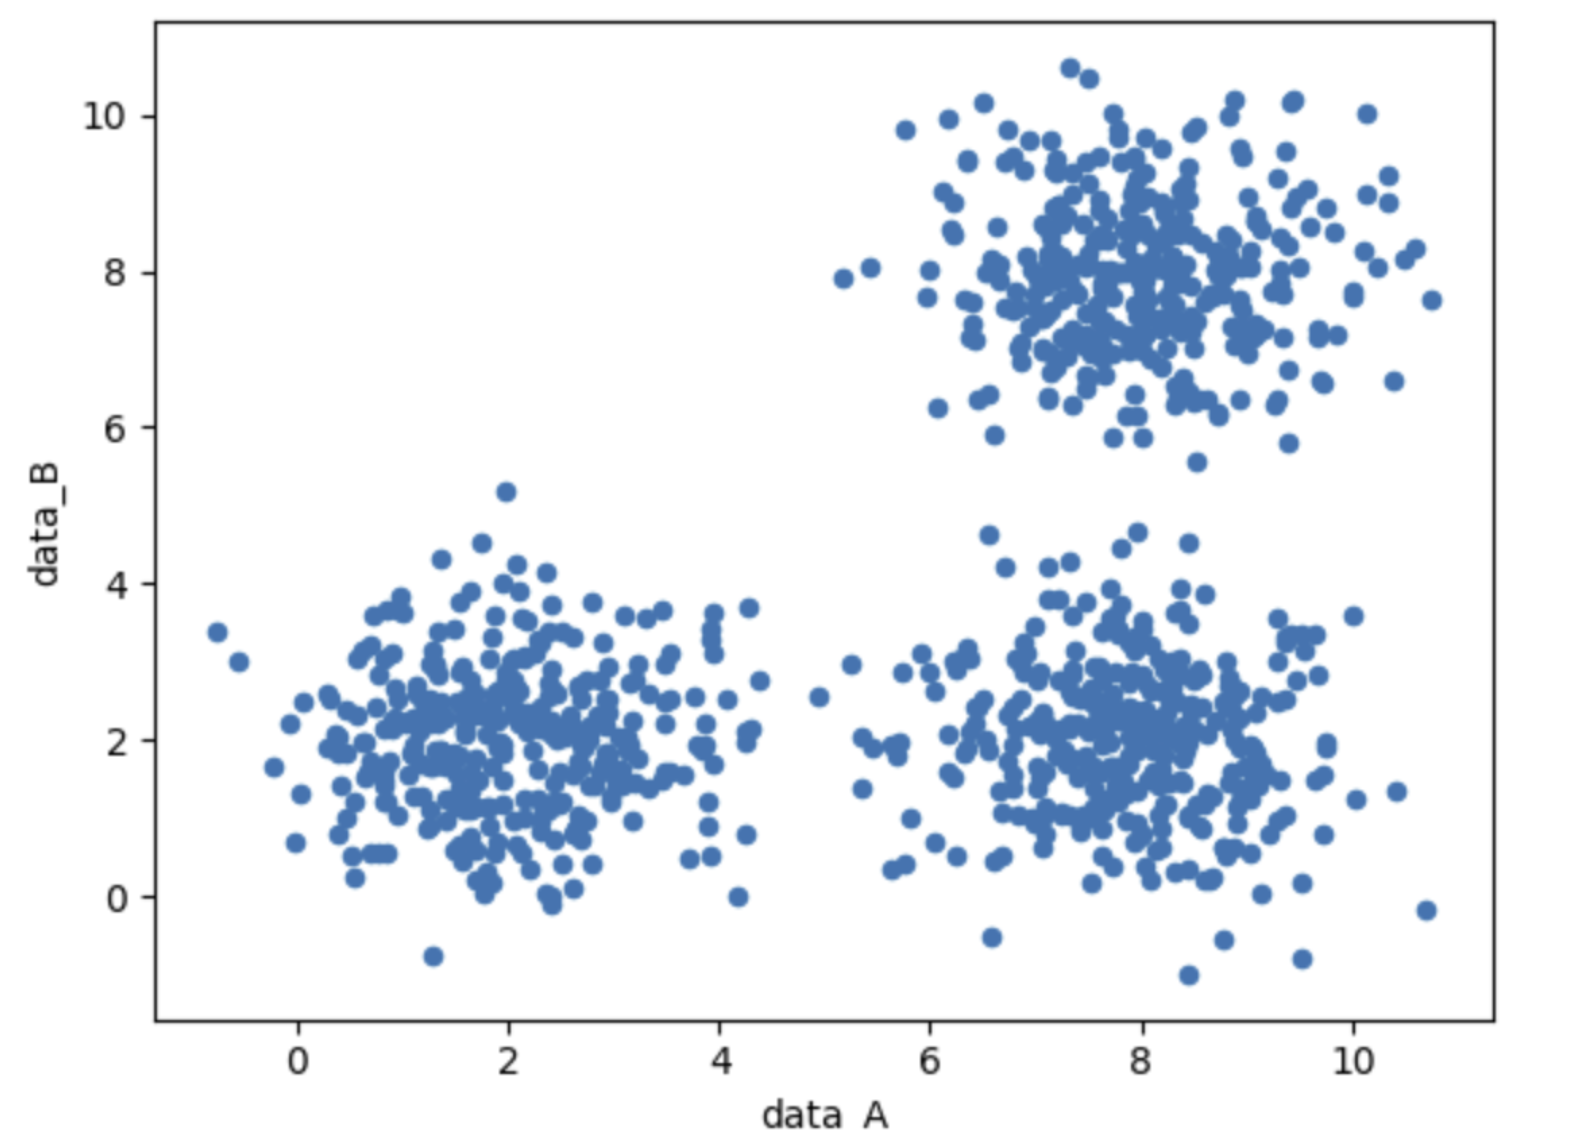

In [41]:
from IPython.display import Image
Image("threeclouds.png")

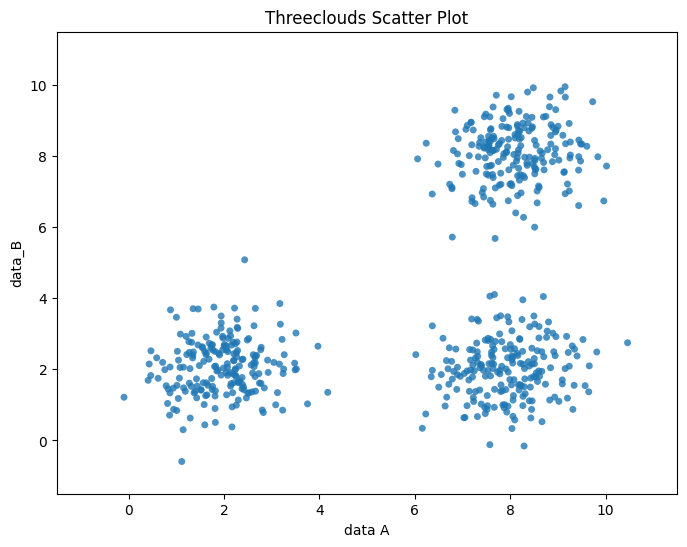

In [86]:

# Set seed for reproducibility
np.random.seed(42)

# Cluster 1 (Bottom Left) - centered around (2, 2)
c1_x = np.random.normal(2, 0.8, 200)
c1_y = np.random.normal(2, 0.8, 200)

# Cluster 2 (Bottom Right) - centered around (8, 2)
c2_x = np.random.normal(8, 0.8, 200)
c2_y = np.random.normal(2, 0.8, 200)

# Cluster 3 (Top Right) - centered around (8, 8)
c3_x = np.random.normal(8, 0.8, 200)
c3_y = np.random.normal(8, 0.8, 200)

# Combine data
x = np.concatenate([c1_x, c2_x, c3_x])
y = np.concatenate([c1_y, c2_y, c3_y])

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=25, alpha=0.8, edgecolors='none')

# Add labels and ticks to match the image
plt.xlabel('data A')
plt.ylabel('data_B')
plt.title("Threeclouds Scatter Plot")
plt.xticks(np.arange(0, 12, 2))
plt.yticks(np.arange(0, 12, 2))

# Adjust plot limits to match original layout
plt.xlim(-1.5, 11.5)
plt.ylim(-1.5, 11.5)

plt.show()


* My explanation:

For the three-cloud scatter plot, there are three sets of data points, each forming its own cluster or “cloud.” Cluster 1 is centered around (2, 2) in the bottom-left, Cluster 2 around (8, 2) in the bottom-right, and Cluster 3 around (8, 8) in the top-right, each generated with a standard deviation of 0.8. By plotting these points on a scatter plot, a bivariate analysis is performed, with data A on the x-axis and data_B on the y-axis. This plot shows how the values of one variable relate to the values of the other. Each cloud is distinct, indicating that within each group, the x and y values are somewhat correlated around the cloud center, while the separation between clouds shows that the groups differ in both variables.

Unlike anticorrelated scatter plots, where one variable tends to increase while the other decreases, these clouds do not follow a single linear relationship; instead, they form clusters, which is also a type of bivariate pattern. Each cloud may represent a subset of data that behaves similarly. The scatter plot helps visually detect relationships, clusters, and patterns in the data. The axis limits from -1.5 to 11.5 ensure all points are clearly visible, demonstrating that a bivariate plot can reveal structure that might not be apparent from one-dimensional summaries.

In terms of bivariate statistics, calculating the overall correlation for all points together could be misleading because the three clouds are distinct. This shows that scatter plots can reveal subgroups and patterns that simple correlation coefficients may not capture. In short, this three-cloud scatter plot is an example of how bivariate plots help explore relationships, identify clusters, and understand the structure of multivariate data.

Would you expect to see a correlation for this challenge problem?  (Hint: does knowing the value of data_A tell you anything about the value of data_B - in particular, whether it is large or small?)  If you managed to reproduce the graph using data, test it yourself using the corr() function.

In [87]:
df = pd.DataFrame({"data_A": x, "data_B": y})
print(df.corr())

          data_A    data_B
data_A  1.000000  0.484585
data_B  0.484585  1.000000


* My answer:

For this challenge problem, a moderate correlation between data_A and data_B is observed (R ≈ 0.485). This occurs because the three-cloud scatter plot has distinct clusters: the bottom-left cloud around (2,2), the bottom-right cloud around (8,2), and the top-right cloud around (8,8). Knowing the value of data_A gives some limited information about data_B—for example, if data_A is small (around 2), then data_B is likely also small (around 2), corresponding to the bottom-left cloud. However, when data_A is larger (around 8), data_B could either be small (bottom-right cloud) or large (top-right cloud), so the value of data_A alone does not reliably predict whether data_B is high or low.

This illustrates the lesson concept that a correlation coefficient summarizes only the overall linear relationship across all points. While the R value of 0.485 indicates a moderate positive trend, it does not capture the cluster structure present in the data. The scatter plot is more informative for detecting these distinct clouds and understanding the bivariate relationships within each subgroup, showing that visual exploration can reveal patterns that numeric correlations alone may not fully describe.

Here is a histogram.  Can you provide data that will approximately re-create this histogram?

It is okay if the precise numbers are not re-created; just the general shape: tailing off on either side, but tailing off to a nonzero number.  (In this case, about 300).

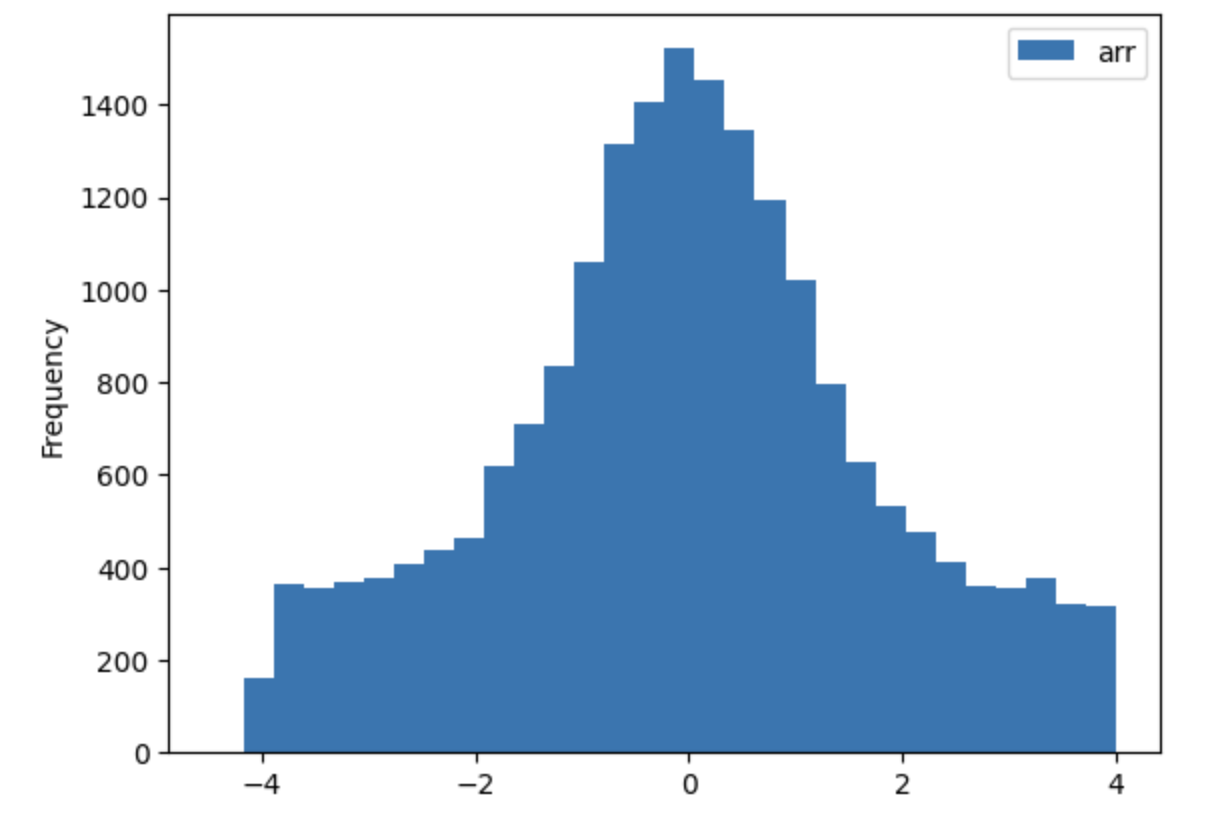

In [ ]:
from IPython.display import Image
Image("histogram.png")

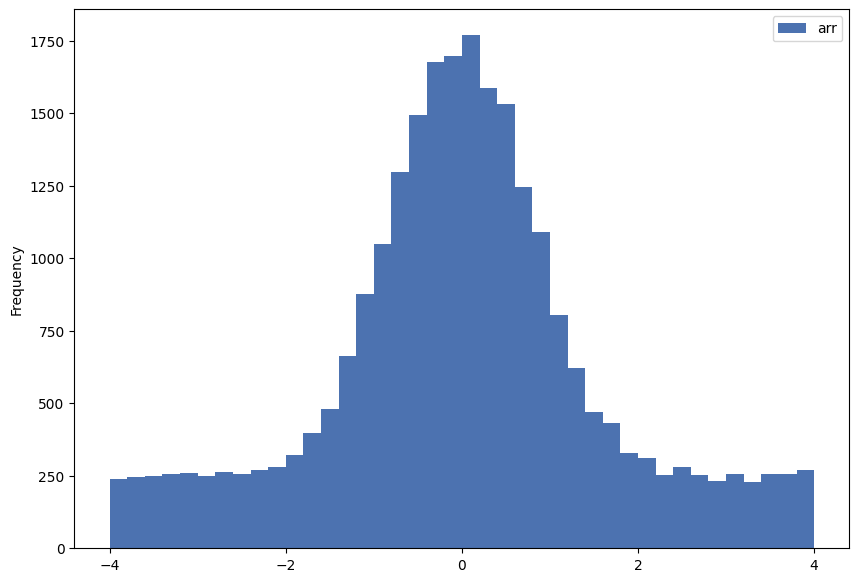

In [73]:

# Generate the two components of the data
# Normal distribution for the center peak
peak_data = np.random.normal(loc=0, scale=0.8, size=15000)

# Uniform distribution for the wider "plateau" base
base_data = np.random.uniform(low=-4, high=4, size=10000)

# Combine them into one array 'arr'
arr = np.concatenate([peak_data, base_data])

# Replicate the specific graph formatting
plt.figure(figsize=(10, 7))

# Create the histogram with 40 bins
plt.hist(arr, bins=40, range=(-4, 4), label='arr', color='#4c72b0')

# Match the labels and axis titles
plt.ylabel('Frequency')
plt.xticks([-4, -2, 0, 2, 4])
plt.legend()

# Display the final graph
plt.show()


* Code explanation;

This code generates a histogram that combines two types of data to create a bell-shaped distribution with nonzero tails. The first part, peak_data = np.random.normal(loc=0, scale=0.8, size=15000), generates 15,000 points from a normal distribution centered at 0 with a small spread, forming the tall central peak of the histogram. The second part, base_data = np.random.uniform(low=-4, high=4, size=10000), generates 10,000 points uniformly across the range -4 to 4, which adds a baseline so that the tails of the histogram do not drop to zero. These two arrays are combined into a single dataset arr, and plt.hist is used to plot the histogram with 40 bins, setting the x-axis range from -4 to 4. The xticks and ylabel commands label the axes and make the histogram easier to read. The result is a histogram with a high central peak and gently tapering tails that remain above zero, simulating a realistic distribution where most values cluster around the center but extreme values still occur.

My interpretation:

This histogram demonstrates how a dataset can have a central tendency with nonzero tails, similar to how some of the series in the homework were distributed. In the homework, scatter plots and pair plots were used to examine relationships between variables, and the correlation coefficient quantified whether knowing one variable helped predict another. Similarly, the histogram shows the distribution of a single variable, and the presence of a central peak with tails suggests that most values cluster around a mean, but there is still variability. If this data were paired with another variable, the uniform tails could reduce the correlation with that variable because extreme values occur independently of the central trend. Just as in the homework, where series like “uniform” and “skewed” had near-zero correlation because one series did not provide information about the other, the uniform component in this histogram would contribute to a weaker linear relationship if correlated with another variable. Therefore, this example reinforces the concept that data distribution affects correlation, and scatter plots or pair plots are useful tools to visualize such relationships.

Create a line plot that shows a sales volume of soft drinks that decreases, then increases over the course of a year, in a U-shaped curve, but with some noise.

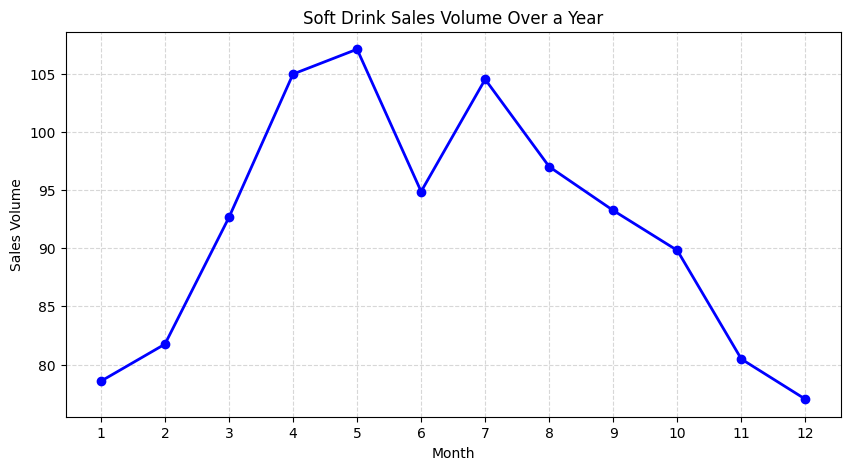

In [74]:


np.random.seed(0)  # for reproducibility

# Generate months
months = np.arange(1, 13)  # 1 to 12 for a year

# Create a U-shaped curve: high at start/end, low in the middle
sales_volume = 100 - (months - 6.5)**2 + np.random.normal(scale=5, size=12)  # quadratic + noise

# Convert to pandas DataFrame for easier plotting
df = pd.DataFrame({'Month': months, 'Sales': sales_volume})

# Plot line graph
plt.figure(figsize=(10,5))
plt.plot(df['Month'], df['Sales'], marker='o', color='blue', linewidth=2)
plt.title('Soft Drink Sales Volume Over a Year')
plt.xlabel('Month')
plt.ylabel('Sales Volume')
plt.xticks(months)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

* Code explanation:

This code generates a line plot showing soft drink sales volume over the course of a year. First, it creates an array months representing the 12 months of the year. The sales_volume is generated using a quadratic function 100 - (months - 6.5)**2 to produce a U-shaped curve, which is lowest in the middle of the year and higher at the start and end. Random noise is added with np.random.normal(scale=5, size=12) to make the data more realistic, so the line does not appear perfectly smooth. The data is then stored in a pandas DataFrame, and plt.plot is used to create the line graph with markers at each month, grid lines for clarity, and appropriate axis labels and title.

* My interpretation:

The resulting line plot shows that soft drink sales decrease during the first half of the year, reach a minimum around the middle months, and then increase in the second half, forming a U-shaped pattern. Similar to the lesson on bivariate plots, this line plot visualizes the relationship between time (months) and sales volume, allowing identification of trends over a continuous variable. The added noise simulates real-world fluctuations, similar to how scatter plots in the lesson showed variability around trends or correlations. Observing the U-shaped pattern is like detecting a relationship in a scatter plot: it highlights how one variable (month) affects another (sales), even if the relationship is nonlinear. This visualization, like the lesson examples, helps interpret patterns, seasonal effects, and potential correlations, which can guide decision-making for inventory, marketing, or promotions.

Create an area plot that shows the sales volume for two brands of soft drinks, one of which is increasing then decreasing, the other decreasing then increasing.

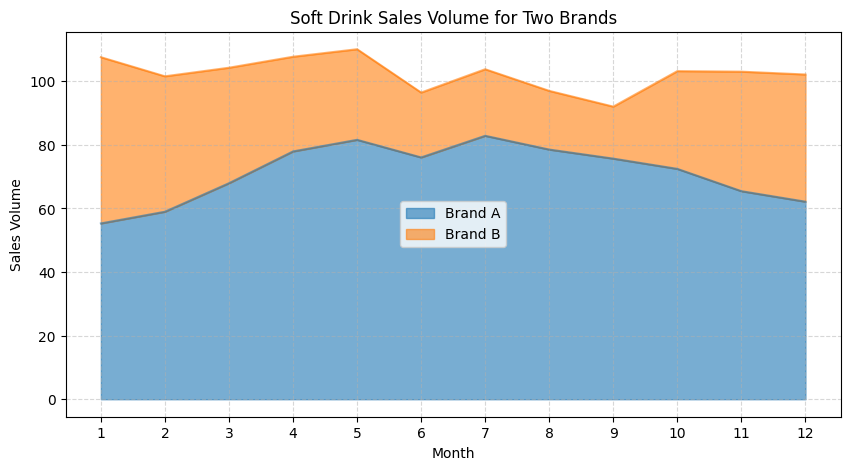

In [75]:

np.random.seed(0)

# Months of the year
months = np.arange(1, 13)

# Brand A: sales increase then decrease (inverted U shape)
brand_A = 50 + 30 * np.sin((months - 1) * np.pi / 12) + np.random.normal(scale=3, size=12)

# Brand B: sales decrease then increase (U shape)
brand_B = 50 - 30 * np.sin((months - 1) * np.pi / 12) + np.random.normal(scale=3, size=12)

# Create DataFrame
df = pd.DataFrame({
    'Month': months,
    'Brand A': brand_A,
    'Brand B': brand_B
})

# Set Month as index for plotting
df.set_index('Month', inplace=True)

# Area plot
df.plot.area(figsize=(10,5), alpha=0.6)
plt.title('Soft Drink Sales Volume for Two Brands')
plt.xlabel('Month')
plt.ylabel('Sales Volume')
plt.xticks(months)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

* Code explanation:

The code generates a line plot showing soft drink sales over 12 months. The months array represents the x-axis (time), and sales_volume is computed using a quadratic function 100 - (months - 6.5)**2 to create a U-shaped trend, with lower sales in the middle months and higher sales at the beginning and end of the year. Random noise is added with np.random.normal(scale=5, size=12) to simulate real-world variability, similar to the scattered data points seen in the lesson’s scatter plots. The data is stored in a pandas DataFrame, which is used to plot the line with markers for each month. Labels, grid lines, and titles are added for clarity. This process mirrors the lesson’s approach of visualizing one variable against another to detect patterns or relationships.

* My interpretaion:

The resulting line plot shows that sales decrease during the first half of the year, reach a minimum around mid-year, and then increase, forming a U-shaped curve. In terms of the lesson on bivariate plots, this demonstrates a relationship between two variables: time (month) and sales volume. The noise in the data represents natural variability, similar to how scatter plots display spread around a trend line. Observing the U-shape is analogous to detecting a pattern in scatter plots or calculating correlations: it shows how one variable changes in relation to another. This visualization helps identify trends, seasonal effects, and fluctuations, which aligns with the lesson’s goal of using plots to interpret data relationships and make informed decisions.

# 4. Storytelling With Data plot



Reproduce any graph of your choice in p. 71-85 of the Storytelling With Data book as best you can.  (The first half of chapter three).

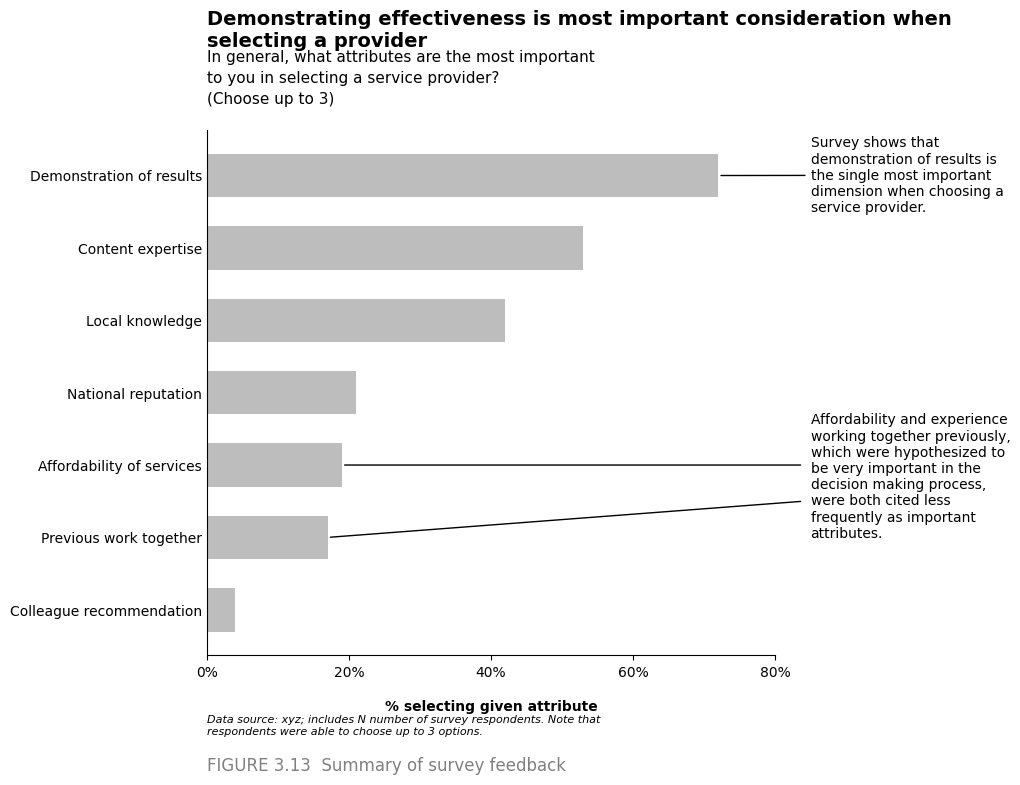

In [83]:


#  Data from Figure 3.13
attributes = [
    "Demonstration of results",
    "Content expertise",
    "Local knowledge",
    "National reputation",
    "Affordability of services",
    "Previous work together",
    "Colleague recommendation"
]
# Estimated percentages based on Figure 3.13
percentages = [72, 53, 42, 21, 19, 17, 4]

# Reverse for top-down horizontal bars
attributes.reverse()
percentages.reverse()

#  Plotting
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(attributes, percentages, color='#bdbdbd', height=0.6)

# Main Title - Added 'pad' to prevent merging with sub-header
plt.title('Demonstrating effectiveness is most important consideration when\nselecting a provider',
          fontsize=14, fontweight='bold', loc='left', pad=60) # Increased pad

# Question Sub-header - Using 'y' coordinate to position it below title
ax.text(0, 1.05, "In general, what attributes are the most important\nto you in selecting a service provider?\n(Choose up to 3)",
        transform=ax.transAxes, fontsize=11, linespacing=1.5)

# X-Axis Styling
ax.set_xlabel('% selecting given attribute', fontsize=10, fontweight='bold', labelpad=15)
ax.set_xlim(0, 80)
ax.set_xticks([0, 20, 40, 60, 80])
ax.set_xticklabels(['0%', '20%', '40%', '60%', '80%'])

# Clean Aesthetics
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', length=0)

# --- Annotations (Notes)
ax.annotate('Survey shows that\ndemonstration of results is\nthe single most important\ndimension when choosing a\nservice provider.',
            xy=(72, 6), xytext=(85, 5.5), fontsize=10,
            arrowprops=dict(arrowstyle='-', color='black'))

ax.text(85, 1, 'Affordability and experience\nworking together previously,\nwhich were hypothesized to\nbe very important in the\ndecision making process,\nwere both cited less\nfrequently as important\nattributes.', fontsize=10)

ax.annotate('', xy=(19, 2), xytext=(84, 2), arrowprops=dict(arrowstyle='-', color='black'))
ax.annotate('', xy=(17, 1), xytext=(84, 1.5), arrowprops=dict(arrowstyle='-', color='black'))

# Footer
plt.text(0, -0.15, "Data source: xyz; includes N number of survey respondents. Note that\nrespondents were able to choose up to 3 options.",
         transform=ax.transAxes, fontsize=8, style='italic')
plt.text(0, -0.22, "FIGURE 3.13  Summary of survey feedback", transform=ax.transAxes, fontsize=12, color='gray')

plt.tight_layout()
plt.subplots_adjust(right=0.65, top=0.85) # Adjusted 'top' to give space for title
plt.show()


* Code Explanation:

This code creates a horizontal bar chart to visualize the importance of various attributes when selecting a service provider, based on survey results. The attributes list contains the categories, and the percentages list contains the corresponding survey percentages. The reverse() function is used to display the bars in top-down order, so the most important attribute appears at the top. A figure and axis are created using plt.subplots, and the bars are plotted with ax.barh, with color and bar height customized for aesthetics. The main title and sub-header are added separately, with padding and text coordinates adjusted to prevent overlap. The x-axis is labeled with percentages and formatted for clarity, while the top and right spines are removed and y-axis ticks are cleaned for a minimalist look. Annotations and arrows are added to highlight notable insights, such as which attributes were cited most or least frequently. Finally, a footer provides the data source and figure label, and plt.tight_layout with plt.subplots_adjust ensures that the layout accommodates titles and annotations properly.

* My Interpretation:

The horizontal bar chart shows that “Demonstration of results” is the most important attribute when choosing a service provider, selected by 72% of respondents. Other factors, like “Content expertise” (53%) and “Local knowledge” (42%), are also considered important, while attributes like “Previous work together” (17%) and “Colleague recommendation” (4%) are cited much less frequently. The chart visually emphasizes these differences using horizontal bars, allowing easy comparison across attributes. This mirrors the lesson on bivariate visualization: one variable (attribute) is plotted against another (percentage of respondents), making it simple to detect patterns, trends, and relative importance. The annotations further guide interpretation, highlighting how some expected important factors, such as affordability, were actually cited less frequently, reinforcing the value of visualizations in summarizing survey results.